In [ ]:
cd /content/drive/MyDrive

/content/drive/MyDrive


In [ ]:
import numpy as np
import cv2
import glob
%matplotlib inline
#The line above is necesary to show Matplotlib's plots inside a Jupyter Notebook
from matplotlib import pyplot as plt

In [ ]:
dirpathU = '/content/drive/MyDrive/separation_u'
dirpathD = '/content/drive/MyDrive/separation_d'
prefix = '1627'
image_format = 'jpg'
square_size = 0.025
width=9
height=6
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

In [ ]:
ls

/content/drive/MyDrive/separation_u/1627195212photo_u.jpg


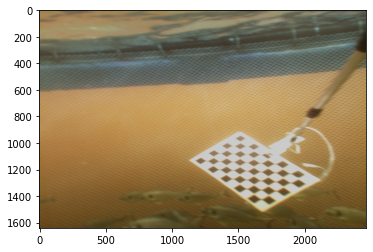

In [ ]:
print(dirpathU+'/1627195212photo_u.'+ image_format)
imgL = cv2.imread(dirpathU+'/1627195212photo_u.'+ image_format)
plt.imshow(imgL)

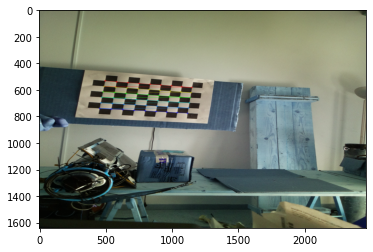

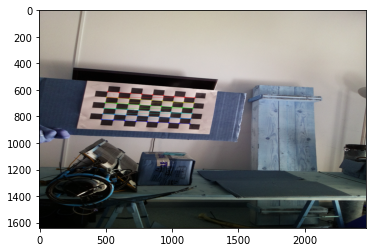

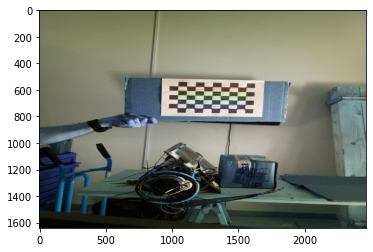

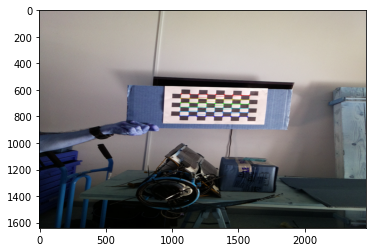

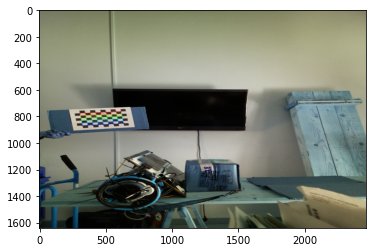

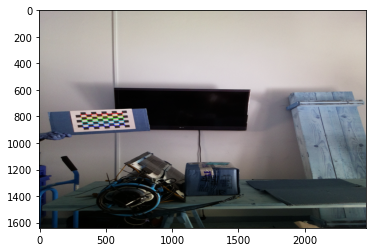

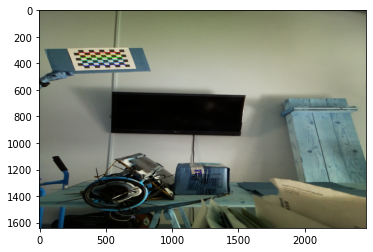

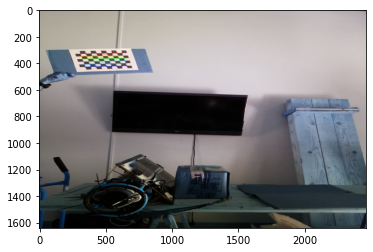

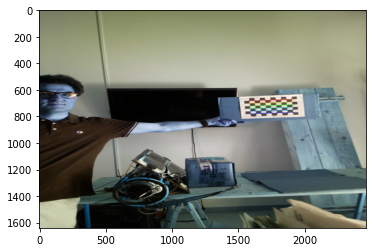

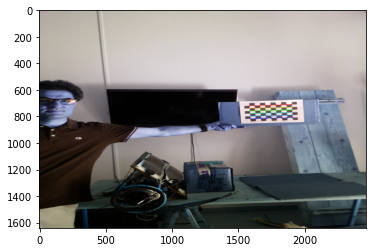

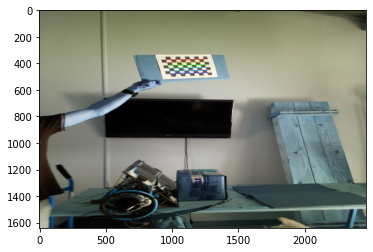

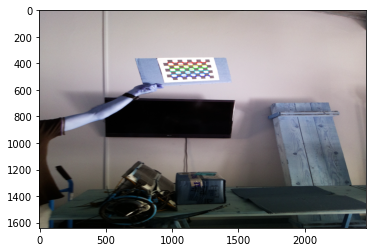

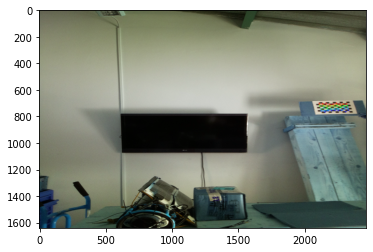

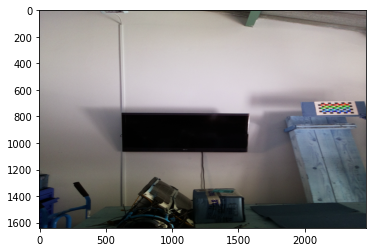

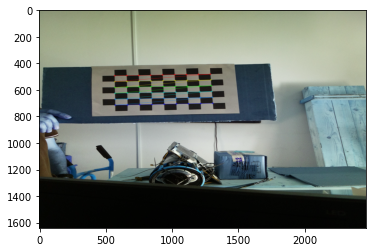

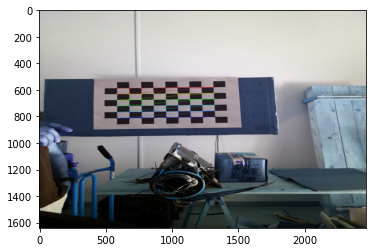

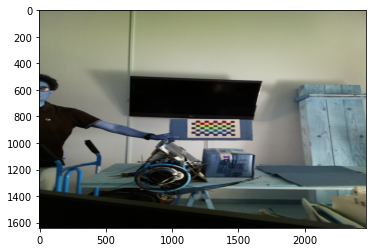

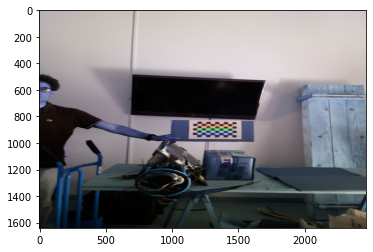

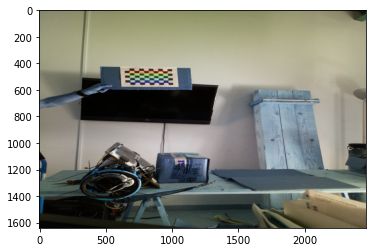

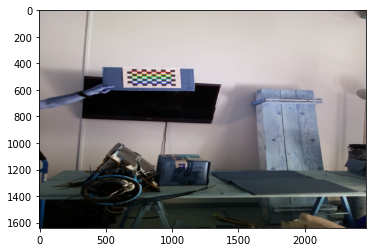

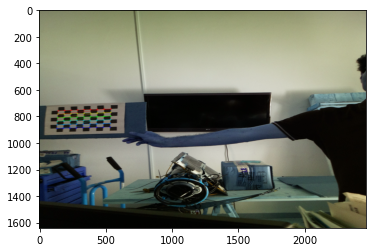

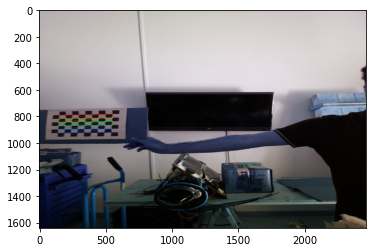

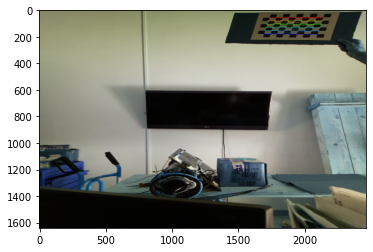

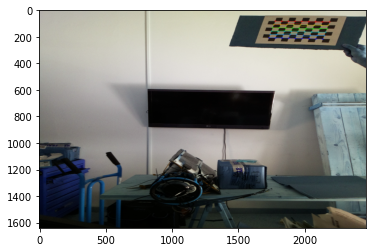

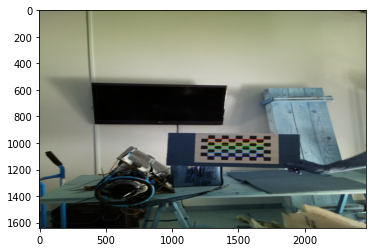

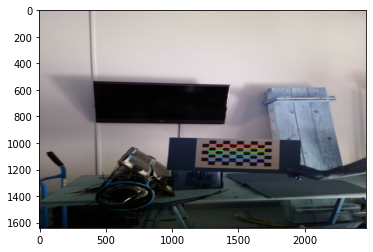

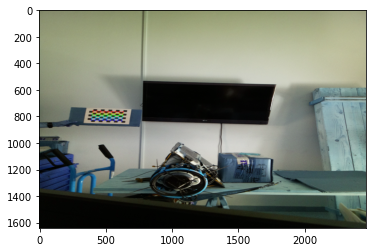

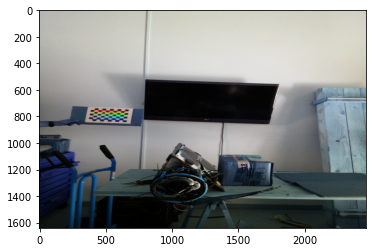

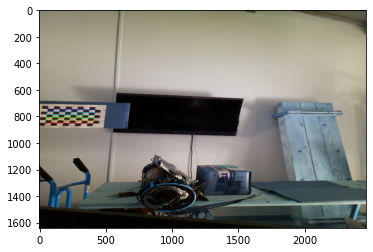

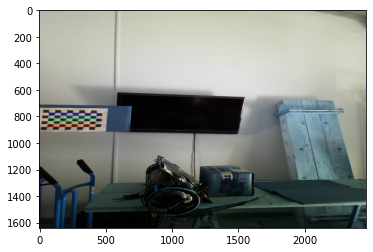

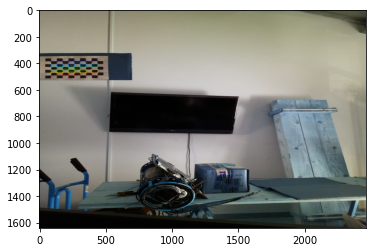

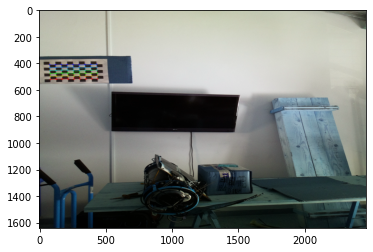

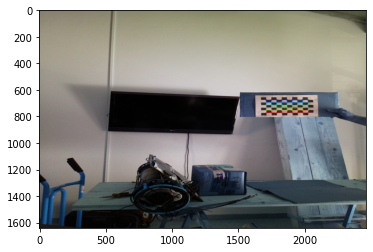

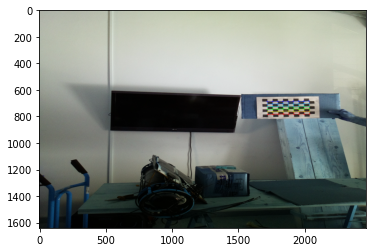

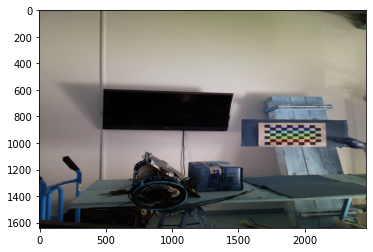

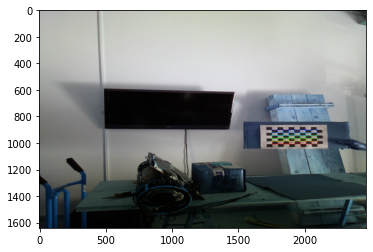

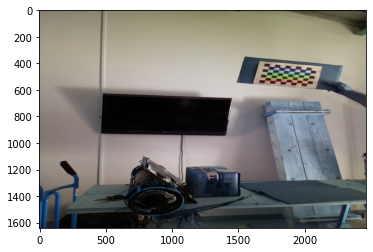

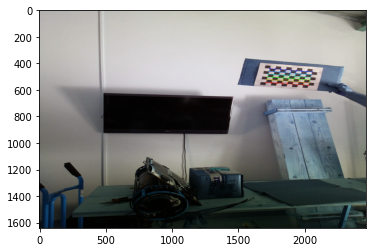

In [ ]:
# Termination criteria for refining the detected corners

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

objp = np.zeros((9*6,3), np.float32)
objp[:,:2] = np.mgrid[0:9,0:6].T.reshape(-1,2)
img_ptsL = []
img_ptsR = []
obj_pts = []

for i in range(1,21):
	imgL = cv2.imread(dirpathU+'/' + prefix + str(i) +'_u.'+ image_format)
	imgR = cv2.imread(dirpathD+'/' + prefix + str(i) +'_d.'+ image_format)
	imgL_gray = cv2.cvtColor(imgL, cv2.COLOR_BGR2GRAY)
	imgR_gray = cv2.cvtColor(imgR, cv2.COLOR_BGR2GRAY)

	outputL = imgL.copy()
	outputR = imgR.copy()
	retR, cornersR =  cv2.findChessboardCorners(outputR,(9,6),None)
	retL, cornersL = cv2.findChessboardCorners(outputL,(9,6),None)
	if retR and retL:
		obj_pts.append(objp)
		cv2.cornerSubPix(imgR_gray,cornersR,(11,11),(-1,-1),criteria)
		cv2.cornerSubPix(imgL_gray,cornersL,(11,11),(-1,-1),criteria)
		cv2.drawChessboardCorners(outputR,(9,6),cornersR,retR)
		cv2.drawChessboardCorners(outputL,(9,6),cornersL,retL)
		plt.imshow(outputR)
		plt.show()
		#cv2.imshow('cornersR',outputR)
		plt.imshow(outputL)
		plt.show()
		#cv2.imshow('cornersL',outputL)
		#cv2.waitKey(0)
		img_ptsL.append(cornersL)
		img_ptsR.append(cornersR)

# Calibrating left camera

retL, mtxL, distL, rvecsL, tvecsL = cv2.calibrateCamera(obj_pts,img_ptsL,imgL_gray.shape[::-1],None,None)
hL,wL= imgL_gray.shape[:2]
new_mtxL, roiL= cv2.getOptimalNewCameraMatrix(mtxL,distL,(wL,hL),1,(wL,hL))

# Calibrating right camera

retR, mtxR, distR, rvecsR, tvecsR = cv2.calibrateCamera(obj_pts,img_ptsR,imgR_gray.shape[::-1],None,None)
hR,wR= imgR_gray.shape[:2]
new_mtxR, roiR= cv2.getOptimalNewCameraMatrix(mtxR,distR,(wR,hR),1,(wR,hR))

In [ ]:
mtxL, distL, mtxR, distR

(array([[2.82516595e+03, 0.00000000e+00, 1.23516503e+03],
        [0.00000000e+00, 1.40829503e+03, 7.92449610e+02],
        [0.00000000e+00, 0.00000000e+00, 1.00000000e+00]]),
 array([[ 0.21486813, -0.75830968, -0.00562732, -0.00315714,  0.82666035]]),
 array([[4.64334901e+03, 0.00000000e+00, 1.27621922e+03],
        [0.00000000e+00, 2.29010590e+03, 8.03161001e+02],
        [0.00000000e+00, 0.00000000e+00, 1.00000000e+00]]),
 array([[ 8.11496472e-01, -8.54706834e+00,  2.16419496e-02,
         -1.64071860e-02,  2.97587690e+01]]))

In [ ]:
roiL,roiR

((17, 6, 2432, 1626), (52, 23, 2367, 1594))

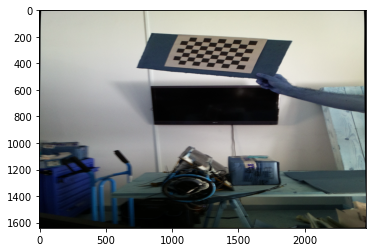

In [ ]:
#test undistortion upper lens
# undistort
img = cv2.imread('/content/drive/MyDrive/separation_u/image11_u.jpg')
h,  w = img.shape[:2]
dst = cv2.undistort(img, mtxL, distL, None, new_mtxL)
# crop the image
x,y,w,h = roiL
#dst = dst[y:y+h, x:x+w]
plt.imshow(dst)

In [ ]:
C

In [ ]:
Rot, Trns, Emat, Fmat 

(array([[ 0.9999735 ,  0.00535649, -0.00493042],
        [-0.00514542,  0.99910985,  0.04186917],
        [ 0.0051503 , -0.04184269,  0.99911094]]), array([[-0.17650414],
        [-3.20314477],
        [ 0.74672675]]), array([[-0.01265494, -0.61203387, -3.2315618 ],
        [ 0.74761602, -0.00338557,  0.17266554],
        [ 3.20396807, -0.15918942, -0.02318293]]), array([[ 9.19794303e-08,  8.89815704e-06,  6.68136293e-02],
        [-1.09411379e-05,  9.91083693e-08,  5.83679067e-03],
        [-6.67740503e-02, -4.00311350e-03,  1.00000000e+00]]))

0.5


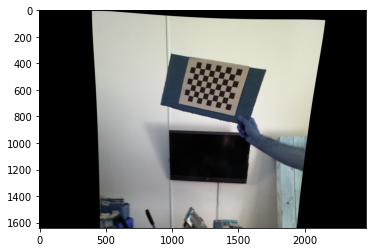

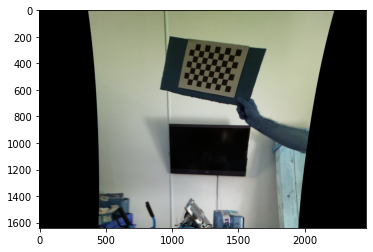

In [ ]:
#p = np.arange(-1.0, 1.1, 0.1)
p = np.arange(0.5, 0.6, 0.1)
for i in p:
    print(i)
    #rect_l, rect_r, proj_mat_l, proj_mat_r, Q, roiL, roiR= cv2.stereoRectify(new_mtxL, distL, new_mtxR, distR, imgL_gray.shape[::-1], Rot, Trns, rectify_scale,(0,0))
    rect_l, rect_r, proj_mat_l, proj_mat_r, Q, roiL, roiR= cv2.stereoRectify(new_mtxL, distL, new_mtxR, distR, imgL_gray.shape[::-1], Rot, Trns, flags=cv2.CALIB_ZERO_DISPARITY, alpha=i)

    #test Image
    left_image = cv2.imread('/content/drive/MyDrive/separation_u/image11_u.jpg')
    right_image = cv2.imread('/content/drive/MyDrive/separation_d/image11_d.jpg')
    height, width = right_image.shape[:2]

    #plt.imshow(right_image)
    #plt.show()

    Left_Stereo_Map= cv2.initUndistortRectifyMap(new_mtxL, distL, rect_l, proj_mat_l, (width, height), cv2.CV_32FC1)
    Right_Stereo_Map= cv2.initUndistortRectifyMap(new_mtxR, distR, rect_r, proj_mat_r,(width, height), cv2.CV_32FC1)

    Left_nice= cv2.remap(left_image,Left_Stereo_Map[0],Left_Stereo_Map[1], cv2.INTER_LINEAR, cv2.BORDER_CONSTANT)
    Right_nice= cv2.remap(right_image,Right_Stereo_Map[0],Right_Stereo_Map[1], cv2.INTER_LINEAR, cv2.BORDER_CONSTANT)
    plt.imshow(Left_nice)
    plt.show()
    plt.imshow(Right_nice)
    plt.show()

In [ ]:
print("Saving parameters ......")
cv_file = cv2.FileStorage("improved_params2.xml", cv2.FILE_STORAGE_WRITE)
cv_file.write("Left_Stereo_Map_x",Left_Stereo_Map[0])
cv_file.write("Left_Stereo_Map_y",Left_Stereo_Map[1])
cv_file.write("Right_Stereo_Map_x",Right_Stereo_Map[0])
cv_file.write("Right_Stereo_Map_y",Right_Stereo_Map[1])
cv_file.release()


Saving parameters ......


In [ ]:
cv_file = cv2.FileStorage("improved_params2.xml", cv2.FILE_STORAGE_READ)
Left_Stereo_Map_x = cv_file.getNode("Left_Stereo_Map_x").mat()
Left_Stereo_Map_y = cv_file.getNode("Left_Stereo_Map_y").mat()
Right_Stereo_Map_x = cv_file.getNode("Right_Stereo_Map_x").mat()
Right_Stereo_Map_y = cv_file.getNode("Right_Stereo_Map_y").mat()


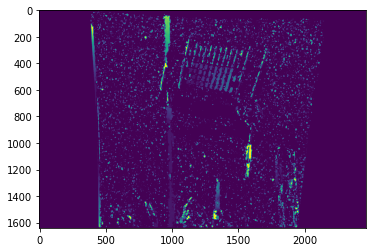

In [ ]:
#other method
gray_left = cv2.cvtColor(Left_nice, cv2.COLOR_BGR2GRAY)
gray_right = cv2.cvtColor(Right_nice, cv2.COLOR_BGR2GRAY)
stereo = cv2.StereoBM_create(numDisparities=16, blockSize=15)
disparity = stereo.compute(gray_left,gray_right)
plt.imshow(disparity)
plt.show()

In [ ]:
def depth_map(imgL, imgR):
    """ Depth map calculation. Works with SGBM and WLS. Need rectified images, returns depth map ( left to right disparity ) """
    # SGBM Parameters -----------------
    window_size = 3  # wsize default 3; 5; 7 for SGBM reduced size image; 15 for SGBM full size image (1300px and above); 5 Works nicely

    left_matcher = cv2.StereoSGBM_create(
        minDisparity=1, # Andrea changed from -1
        numDisparities=5*16,  # max_disp has to be dividable by 16 f. E. HH 192, 256
        blockSize=window_size,
        P1=8 * 3 * window_size,
        # wsize default 3; 5; 7 for SGBM reduced size image; 15 for SGBM full size image (1300px and above); 5 Works nicely
        P2=32 * 3 * window_size,
        disp12MaxDiff=12,
        uniquenessRatio=10,
        speckleWindowSize=50,
        speckleRange=32,
        preFilterCap=63,
        mode=cv2.STEREO_SGBM_MODE_SGBM_3WAY
    )
    right_matcher = cv2.ximgproc.createRightMatcher(left_matcher)
    # FILTER Parameters
    lmbda = 80000
    sigma = 1.3
    visual_multiplier = 6

    wls_filter = cv2.ximgproc.createDisparityWLSFilter(matcher_left=left_matcher)
    wls_filter.setLambda(lmbda)

    wls_filter.setSigmaColor(sigma)
    displ = left_matcher.compute(imgL, imgR)  # .astype(np.float32)/16
    dispr = right_matcher.compute(imgR, imgL)  # .astype(np.float32)/16
    displ = np.int16(displ)
    dispr = np.int16(dispr)
    filteredImg = wls_filter.filter(displ, imgL, None, dispr)  # important to put "imgL" here!!!

    filteredImg = cv2.normalize(src=filteredImg, dst=filteredImg, beta=0, alpha=255, norm_type=cv2.NORM_MINMAX);
    filteredImg = np.uint8(filteredImg)

    return filteredImg

In [ ]:
gray_left = cv2.cvtColor(Left_nice, cv2.COLOR_BGR2GRAY)
gray_right = cv2.cvtColor(Right_nice, cv2.COLOR_BGR2GRAY)
disparity_image = depth_map(gray_left, gray_right)  # Get the disparity map

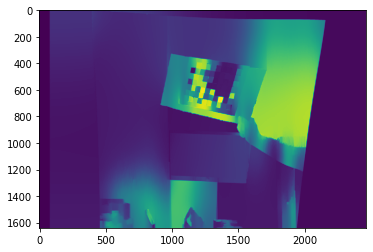

In [ ]:
plt.imshow(disparity_image)
plt.show()